In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
dict={'rate':[12,13,14,14],'states':['a','b','c','d']}
df1=pd.DataFrame(dict)
df1=df1.set_index("states")
df1
df2=pd.DataFrame(dict,index=[21,22,23,24])
df2.loc['h']=[1,2]
df2.loc[22,'states']=10
df2

,rate,states
21,12,a
22,13,10
23,14,c
24,14,d
h,1,2


In [87]:
df=pd.read_csv("simple_linear_regression.csv")
df.head(5)

,Experience_Years,Salary
0,7,15462.629112
1,20,33781.200143
2,15,20639.949392
3,11,21217.664489
4,8,14408.180125


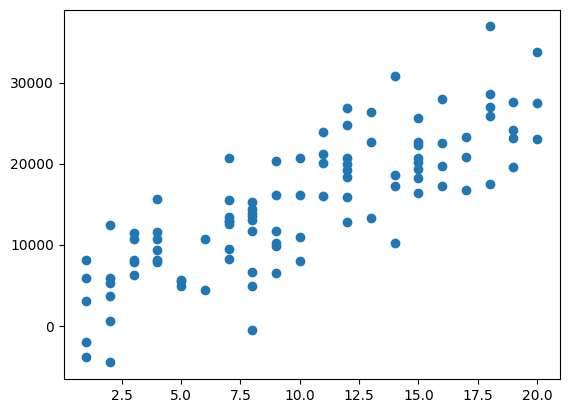

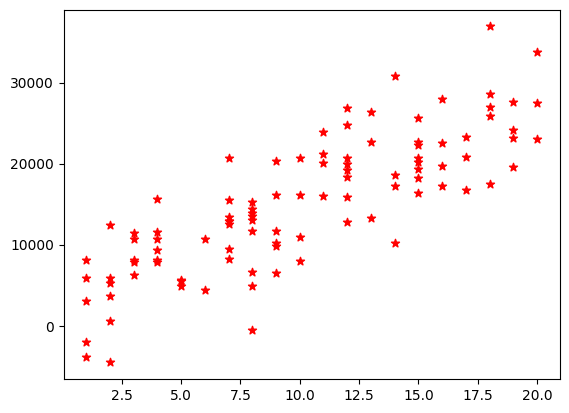

In [88]:
plt.scatter(df["Experience_Years"],df["Salary"])
plt.show()
plt.scatter(df["Experience_Years"],df["Salary"],color='red',marker='*')


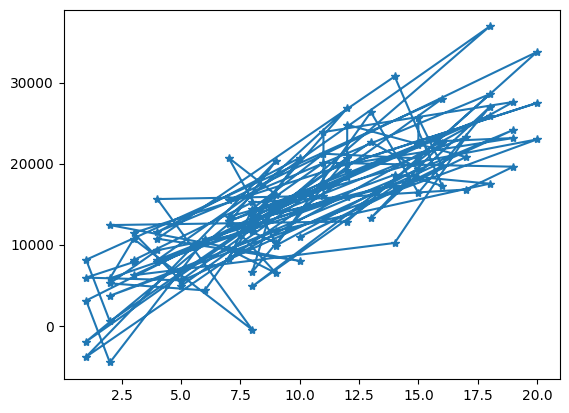

In [89]:
plt.plot(df["Experience_Years"],df["Salary"],marker='*')

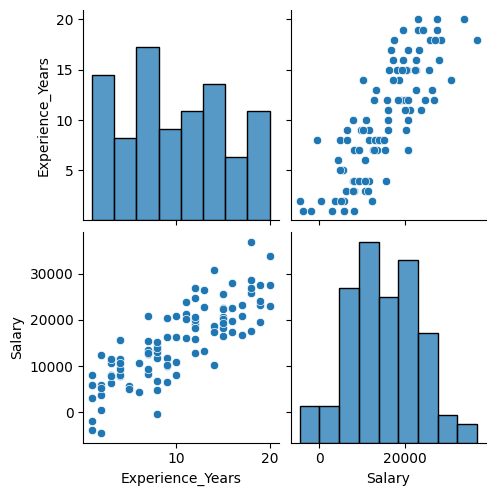

In [90]:
sns.pairplot(df)

In [91]:
x=df["Experience_Years"]
print(type(x))
np.array(x).shape

<class 'pandas.core.series.Series'>


(100,)

In [92]:
x=df[["Experience_Years"]]
print(type(x))  # since its a dataframe it is 2D array and the previous one is a series which is 1D array
np.array(x).shape

<class 'pandas.core.frame.DataFrame'>


(100, 1)

In [93]:
y=df["Salary"]
print(type(y)) #no need to convert it into 2D array since it is the target variable

<class 'pandas.core.series.Series'>


In [94]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.75,random_state=42)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)
# #1. fit_transform()
# fit() → Learns parameters from the data
# transform() → Applies the transformation using those learned parameters.

# 2. transform()

# 👉 This only applies transformation, using already learned parameters.
# Uses same mean and std learned from training data
# Does NOT recompute anything
# dont do dataleakage by applying fit_transform to test data

In [95]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression(n_jobs=-1)
# Initialize Linear Regression model with parallel processing
#Tells the model to use all available CPU cores during training (can speed things up on large datasets).
lr.fit(x_train,y_train)

LinearRegression(n_jobs=-1)

In [96]:
print("Coefficient or slope:",lr.coef_)  #1 unit change in x leads to 6894.73.. units of change in y
print("Intercept:",lr.intercept_) #at what point experience=0

Coefficient or slope: [6894.78390033]
Intercept: 14868.93129693494


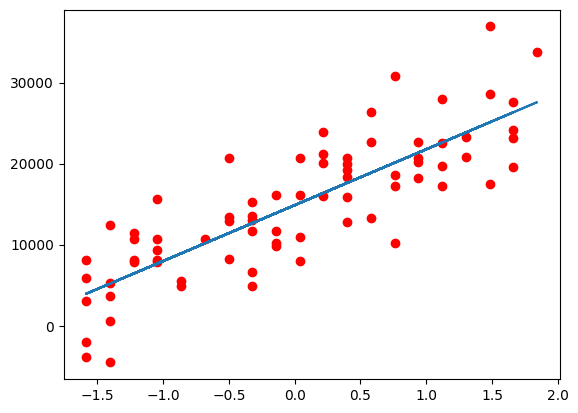

In [97]:
# Training Data Plot
plt.scatter(x_train,y_train,color='red')
plt.plot(x_train,lr.predict(x_train))

# Prediction on Test Data
salary=intercept+ coefficient*experience
y_pred=14868+ 6894.73(x_test)

In [98]:
y_pred=lr.predict(x_test)

In [99]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mae)
print(mse)
rmse

3814.27673859539
24640004.46294062


np.float64(4963.869907938827)

**R square**

**R^2=1-SSR/SS1**

coefficient of determination SSR =sum of squares of residuals SST=total sum of squares

In [100]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.6270621832624177


**ADJUSTED R2=1-[(1-R2)*(n-1)/(n-k-1)]**

n:no.of observations,k:no of predictor variables

In [101]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1) 

0.610847495578175

In [102]:
# Prediction
print(lr.predict([[20]])) #20 years of experience
#with transformation,the result changes since the model was trained on transformed data, so we need to transform the input before prediction
lr.predict(sc.transform([[20]]))

[152764.60930352]


C:\Users\Varshitha\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([27572.39860653])

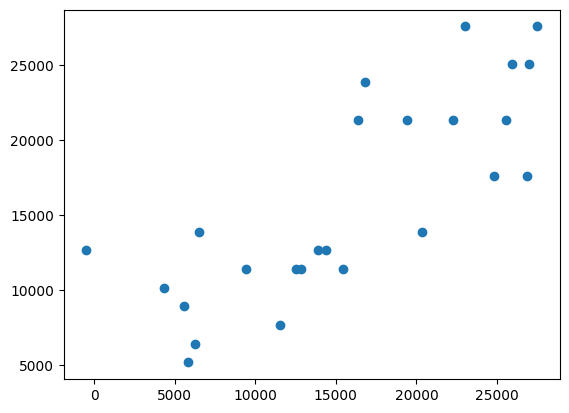

In [103]:
plt.scatter(y_test,y_pred)

**OLS LINEAR REGRESSION**

In [104]:
import statsmodels.api as sm
model=sm.OLS(y_train,x_train).fit()
model.predict(x_test)

array([ 8972.03108942, -4709.90171792,  6484.40694263, -8441.3379381 ,
        6484.40694263, 12703.4673096 ,  6484.40694263, -2222.27757113,
       -2222.27757113, -3466.08964452,  2752.97072245, -3466.08964452,
        6484.40694263, 10215.84316281, -3466.08964452, -2222.27757113,
       -3466.08964452,  -978.46549774, -9685.15001149,  -978.46549774,
       -7197.52586471, -5953.71379131, 12703.4673096 ,  2752.97072245,
       10215.84316281])

In [105]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Salary   R-squared (uncentered):                   0.164
Model:                            OLS   Adj. R-squared (uncentered):              0.152
Method:                 Least Squares   F-statistic:                              14.47
Date:                Mon, 15 Jun 2026   Prob (F-statistic):                    0.000290
Time:                        21:03:32   Log-Likelihood:                         -830.50
No. Observations:                  75   AIC:                                      1663.
Df Residuals:                      74   BIC:                                      1665.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

**POLYNOMIAL REGRESSION**

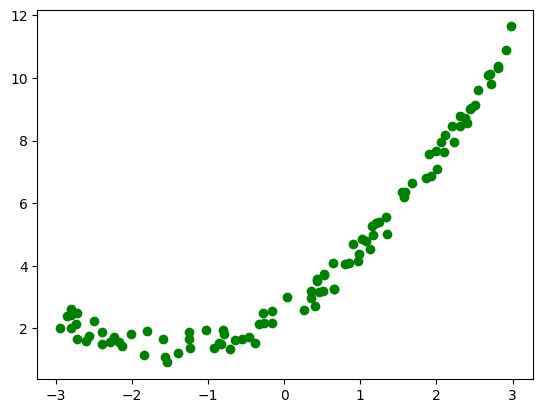

In [106]:
X = 6 * np.random.rand(100,1) - 3
Y =0.5* X**2 + 1.5*X + 2 + np.random.rand(100,1)
plt.scatter(X,Y,color='green')

In [107]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.75,random_state=42)

R2 SCORE: 0.6663432654574104


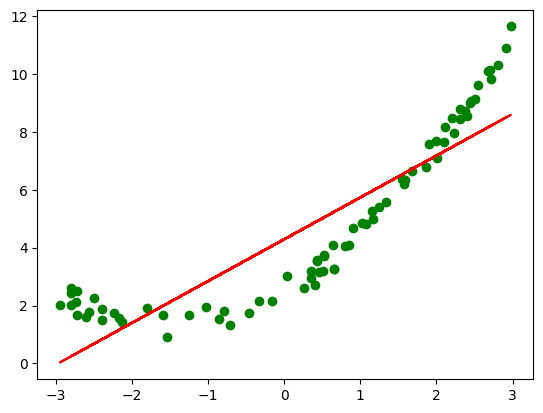

In [108]:
# Let's implement through simple Linear regression and see how it performs on this non-linear data
from sklearn.linear_model import LinearRegression
lr1=LinearRegression()
lr1.fit(X_train,Y_train)
score1=r2_score(Y_test,lr1.predict(X_test))
print("R2 SCORE:",score1)
plt.plot(X_train,lr1.predict(X_train),color='red')
plt.scatter(X_train,Y_train,color='green')

y=a+bx1

y=a+b1x1+b2x1^2

y=a+b1x1+b2x1^2+b3x^3

In [109]:
# Let's apply polynomial transformation to make it linear
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)
X_train_poly #1st column is bias term, 2nd column is X and 3rd column is X^2

array([[ 1.00000000e+00,  1.86650036e+00,  3.48382360e+00],
       [ 1.00000000e+00, -2.79676763e+00,  7.82190919e+00],
       [ 1.00000000e+00,  1.07151352e+00,  1.14814122e+00],
       [ 1.00000000e+00, -2.39386346e+00,  5.73058225e+00],
       [ 1.00000000e+00,  4.00641546e-01,  1.60513649e-01],
       [ 1.00000000e+00,  1.15026145e+00,  1.32310140e+00],
       [ 1.00000000e+00, -2.72436815e+00,  7.42218181e+00],
       [ 1.00000000e+00, -2.79326526e+00,  7.80233079e+00],
       [ 1.00000000e+00,  2.43743077e+00,  5.94106878e+00],
       [ 1.00000000e+00, -7.88853918e-01,  6.22290505e-01],
       [ 1.00000000e+00, -8.61742309e-01,  7.42599807e-01],
       [ 1.00000000e+00,  2.81354374e+00,  7.91602838e+00],
       [ 1.00000000e+00,  4.36355457e-01,  1.90406085e-01],
       [ 1.00000000e+00,  2.70183705e+00,  7.29992342e+00],
       [ 1.00000000e+00,  5.23030779e-01,  2.73561196e-01],
       [ 1.00000000e+00,  2.97549596e+00,  8.85357618e+00],
       [ 1.00000000e+00, -2.94400267e+00

In [110]:
lr1.fit(X_train_poly,Y_train)
Y_pred_poly=lr1.predict(X_test_poly)
score1=r2_score(Y_test,Y_pred_poly)
print("R2 SCORE:",score1)
print(lr1.coef_)
print(lr1.intercept_)

R2 SCORE: 0.985341991398358
[[0.         1.48916338 0.4776023 ]]
[2.59232866]


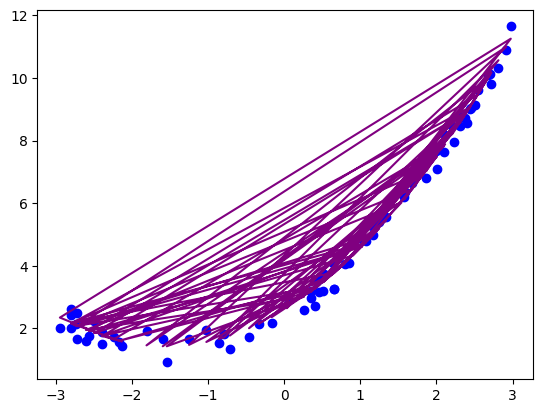

In [111]:
plt.plot(X_train,lr1.predict(X_train_poly),color='purple')
plt.scatter(X_train,Y_train,color='blue')

In [112]:
# Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

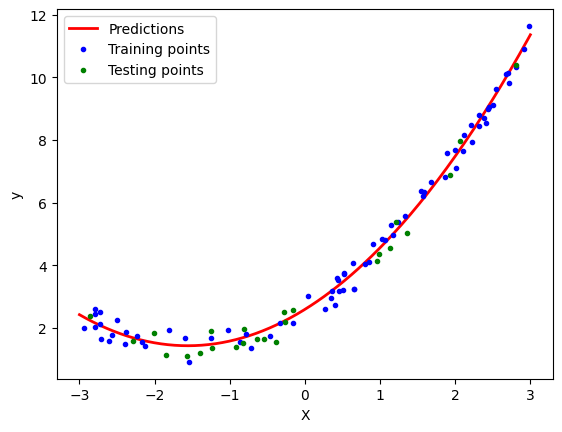

In [113]:
Y_new = lr1.predict(X_new_poly)

plt.plot(X_new, Y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, Y_train, "b.", label="Training points")
plt.plot(X_test, Y_test, "g.", label="Testing points")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

**PIPELINE CONCEPT**



In [114]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg = LinearRegression()

    poly_regression = Pipeline([
        ("poly_features", poly_features),
        ("lin_reg", lin_reg)
    ])

    poly_regression.fit(X_train, Y_train)
    y_pred_new = poly_regression.predict(X_new)

    # plotting prediction line
    plt.plot(X_new, y_pred_new, "r-", label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, Y_train, "b.", linewidth=3)
    plt.plot(X_test, Y_test, "g.", linewidth=3)

    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4, 4, 0, 10])
    plt.show()

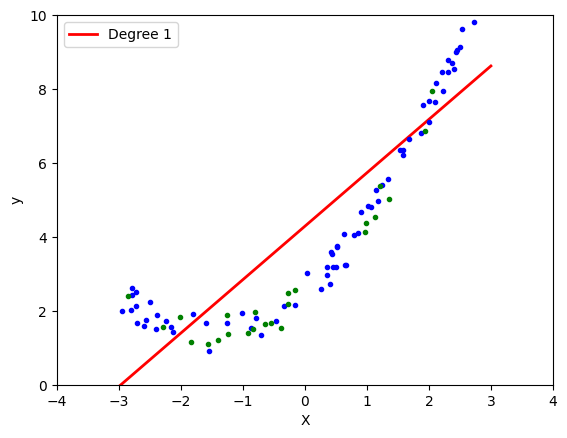

In [115]:
poly_regression(1)

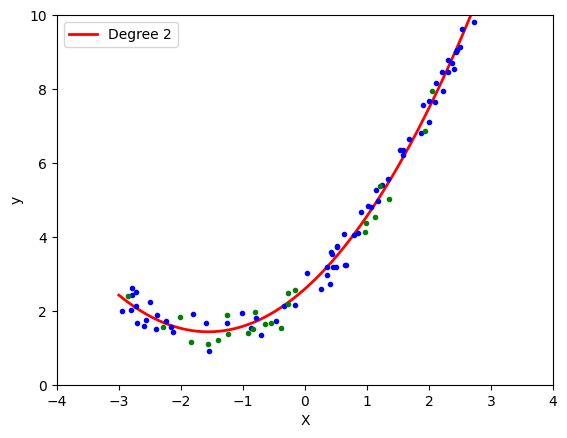

In [116]:
poly_regression(2)

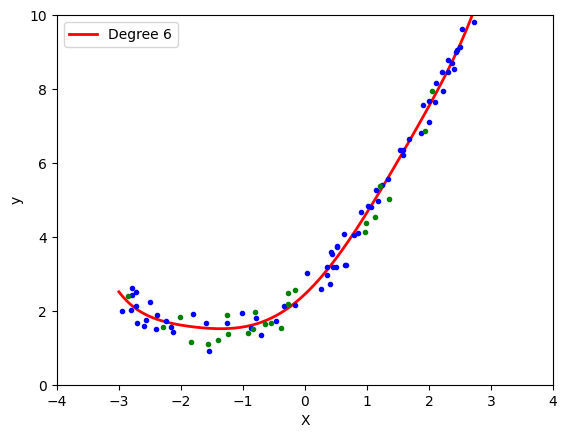

In [117]:
poly_regression(6)

**RIDGE REGRESSION**

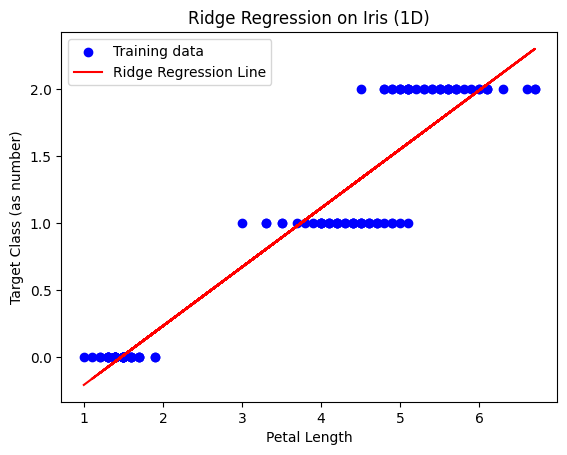

Mean Squared Error: 0.06351096827725951
Ridge Coefficients: [0.43946567]


In [118]:
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_iris

# Load the iris dataset
data = load_iris()
x = data.data[:, 2].reshape(-1, 1)  # Use just one feature: petal length
y = data.target

# Train/test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Create Ridge Regression model
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)

# Predict
y_pred = ridge.predict(x_test)

# Plot
plt.scatter(x_train, y_train, color='blue', label='Training data')
plt.plot(x_train, ridge.predict(x_train), color='red', label='Ridge Regression Line')
plt.legend()
plt.xlabel("Petal Length")
plt.ylabel("Target Class (as number)")
plt.title("Ridge Regression on Iris (1D)")
plt.show()

# Evaluation
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Ridge Coefficients:", ridge.coef_)


In [119]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_iris

data = load_iris()
x = data.data
y = data.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Create Ridge Regression model with alpha=1.0
ridge = Ridge(alpha=1.0)

# Train the model
ridge.fit(x_train, y_train)
y_pred = ridge.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Ridge Coefficients:", ridge.coef_)

Mean Squared Error: 0.039097243116783545
Ridge Coefficients: [-0.11779035 -0.05071844  0.28692395  0.47208952]


ValueError: x and y must be the same size

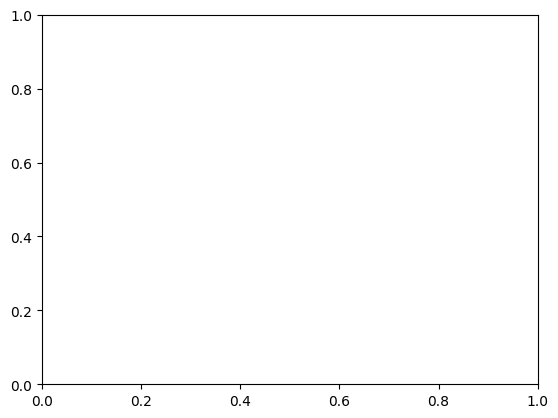

In [120]:
plt.scatter(x_train,y_train)
plt.plot(x_train,lr.predict(x_train))
# Plotting error: You're trying to plot a regression line 
# over multi-dimensional input (x_train), but plt.plot works best with 1D data.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_boston

data = load_boston()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create Ridge Regression model with alpha=1.0
ridge = Ridge(alpha=1.0)

# Train the model
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Ridge Coefficients:", ridge.coef_)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, RidgeCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_boston
boston = load_boston()
boston_df=pd.DataFrame(boston.data,columns=boston.feature_name
s)
#target variable
boston_df['Price']=boston.target
#Exploration
plt.figure(figsize = (10, 10))
sns.heatmap(boston_df.corr(), annot = True)
#There are cases of multicolinearity, we will drop a few

In [ ]:
#There are cases of multicolinearity, we will drop a few
# columns
boston_df.drop(columns = ["INDUS", "NOX"], inplace = True)
#we will log the LSTAT Column
boston_df.LSTAT = np.log(boston_df.LSTAT)
# Note that we logged the LSTAT column as it doesn’t have a linear relationship with
# the price column. Linear models assume a linear relationship between x and y
# variables.

In [ ]:
#data splitting and scaling
features = boston_df.columns[0:11]
target = boston_df.columns[-1]
#X and y values
X = boston_df[features].values
y = boston_df[target].values
#splot
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.3, random_state=17)
print("The dimension of X_train is {}".format(X_train.shape))
print("The dimension of X_test is {}".format(X_test.shape))
#Scale features
scaler = StandardScaler()
X_train = scaler.fit_transf

**LASSO REGRESSION**

Lasso Regression
Selecting Optimal Alpha Values Using Cross-Validation in Sklearn
We may need to try out different alpha values to find the optimal constraint value.
For this case, we can use the cross-validation model in the sklearn package. This
will try out different combinations of alpha values and then choose the best model.

In [ ]:
#Using the linear CV model
from sklearn.linear_model import LassoCV
#Lasso Cross validation
lasso_cv = LassoCV(alphas = [0.0001, 0.001,0.01, 0.1, 1, 10],
random_state=0).fit(X_train, y_train)
#score
print(lasso_cv.score(X_train, y_train))
print(lasso_cv.score(X_test, y_test))

In [ ]:
#Ridge Regression Model
ridgeReg = Ridge(alpha=10)
ridgeReg.fit(X_train,y_train)
#train and test score for ridge regression
train_score_ridge = ridgeReg.score(X_train, y_train)
test_score_ridge = ridgeReg.score(X_test, y_test)
print("The train score for ridge model is{}".format(train_score_ridge))
print("The test score for ridge model is{}".format(test_score_ridge))